# RQ1 Exploratory Data Analysis

**Data source:** `data_processed/selected_raw/hh_selected_raw.csv`.  
**Unit of analysis:** household.  
**Main household weight:** `H_GEW`.

## Table of Contents

1. [Setup and Data Loading](#1.-Setup-and-Data-Loading)
2. [Household Sample and Variable Validity](#2.-Household-Sample-and-Variable-Validity)
3. [Household Type and Car Ownership](#3.-Household-Type-and-Car-Ownership)
4. [Economic Status and Car Ownership](#4.-Economic-Status-and-Car-Ownership)
5. [Spatial Context and Car Ownership](#5.-Spatial-Context-and-Car-Ownership)
6. [Economic Status by Household Type and Car Ownership](#6.-Economic-Status-by-Household-Type-and-Car-Ownership)

`household_type` is constructed outside this notebook with `src/build_household_type.py`. The notebook validates and uses the stored column rather than rebuilding it each time.

For speed and stability, this notebook loads only the household selected CSV by default. Person, car, and trip selected CSV paths are kept in `DATA_PATHS` and should be loaded only inside future sections that explicitly need them.

## 1. Setup and Data Loading

This section defines shared labels, category orders, valid-sample helpers, weighted crosstab helpers, publication-table formatting, and reusable 100% stacked-bar plotting functions. Later EDA sections only specify variables, denominators, output names, and short interpretations.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data_processed'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'/'descriptive'
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATHS = {
    'households': DATA_DIR / 'selected_raw' / 'hh_selected_raw.csv',
    'persons': DATA_DIR / 'selected_raw' / 'persons_selected_raw.csv',
    'cars': DATA_DIR / 'selected_raw' / 'cars_selected_raw.csv',
    'trips': DATA_DIR / 'selected_raw' / 'trips_selected_raw.csv',
}

CAR_COUNT_GROUP_ORDER = ['0 cars', '1 car', '2+ cars']
CAR_COUNT_COLORS = {'0 cars': '#154C79', '1 car': '#4F86C6', '2+ cars': '#F4C95D'}
CAR_COUNT_TEXT_COLORS = {'0 cars': 'white', '1 car': 'white', '2+ cars': '#1A1A1A'}

HOUSEHOLD_TYPE_LABELS = {
    'family_household': 'Family household',
    'young_household': 'Young household',
    'adult_household': 'Adult household',
    'senior_household': 'Senior household',
    'unknown': 'Unknown',
}
HOUSEHOLD_TYPE_ORDER = ['family_household', 'young_household', 'adult_household', 'senior_household', 'unknown']
HOUSEHOLD_TYPE4_ORDER = [x for x in HOUSEHOLD_TYPE_ORDER if x != 'unknown']

REGIOSTARR7_LABELS = {
    71: 'Urban region — metropolis',
    72: 'Urban region — regiopolis / large city',
    73: 'Urban region — medium-sized city / urban area',
    74: 'Urban region — small-town / rural area',
    75: 'Rural region — central city',
    76: 'Rural region — medium-sized city / urban area',
    77: 'Rural region — small-town / rural area',
}
REGIOSTARR7_ORDER = list(REGIOSTARR7_LABELS)

OEK_STATUS_LABELS = {
    1: 'Very low',
    2: 'Low',
    3: 'Medium',
    4: 'High',
    5: 'Very high',
}
OEK_STATUS_ORDER = list(OEK_STATUS_LABELS)
OEK_STATUS_COLORS = {
    'Very low': '#154C79',
    'Low': '#4F86C6',
    'Medium': '#8DB7E2',
    'High': '#F4D35E',
    'Very high': '#D99A00',
}

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def ensure_household_level(data, id_col='H_ID'):
    duplicate_count = data[id_col].duplicated().sum()
    if duplicate_count:
        raise ValueError(f'Expected one row per household, but found {duplicate_count:,} duplicate {id_col} rows.')
    return data.copy()

def add_car_count_group(data):
    out = data.copy()
    if 'car_count_group' in out.columns:
        out['car_count_group'] = out['car_count_group'].where(out['car_count_group'].isin(CAR_COUNT_GROUP_ORDER))
        return out

    if 'H_ANZAUTO' in out.columns:
        car_count = pd.to_numeric(out['H_ANZAUTO'], errors='coerce')
        out['car_count_group'] = pd.Series(pd.NA, index=out.index, dtype='object')
        out.loc[car_count == 0, 'car_count_group'] = '0 cars'
        out.loc[car_count == 1, 'car_count_group'] = '1 car'
        out.loc[(car_count >= 2) & (car_count < 99), 'car_count_group'] = '2+ cars'
    elif 'anzauto_gr3' in out.columns:
        car_group = pd.to_numeric(out['anzauto_gr3'], errors='coerce')
        out['car_count_group'] = car_group.map({0: '0 cars', 1: '1 car', 2: '2+ cars'})
    else:
        raise KeyError('Need H_ANZAUTO or anzauto_gr3 to create car_count_group.')
    return out

def make_valid_sample(data, category_orders, weight='H_GEW'):
    valid = ensure_household_level(data)
    valid[weight] = pd.to_numeric(valid[weight], errors='coerce')
    mask = valid[weight].notna() & (valid[weight] > 0)
    for col, order in category_orders.items():
        mask &= valid[col].isin(order)
    valid = valid.loc[mask].copy()
    for col, order in category_orders.items():
        valid[col] = pd.Categorical(valid[col], categories=order, ordered=True)
    return valid

def weighted_row_share_crosstab(data, index, columns, weight, index_order, column_order):
    index_cols = [index] if isinstance(index, str) else list(index)
    if len(index_cols) == 1:
        target_index = pd.Index(index_order, name=index_cols[0])
    else:
        target_index = pd.MultiIndex.from_product(index_order, names=index_cols)

    weighted_n = (
        data.pivot_table(index=index_cols, columns=columns, values=weight, aggfunc='sum', observed=False, fill_value=0)
        .reindex(index=target_index, columns=column_order, fill_value=0.0)
    )
    unweighted_n = (
        data.assign(_n=1)
        .pivot_table(index=index_cols, columns=columns, values='_n', aggfunc='sum', observed=False, fill_value=0)
        .reindex(index=target_index, columns=column_order, fill_value=0)
        .astype('int64')
    )
    row_totals = weighted_n.sum(axis=1).replace(0, np.nan)
    row_share = weighted_n.div(row_totals, axis=0).mul(100).fillna(0)
    return row_share, unweighted_n

def make_publication_table(row_share, unweighted_n, include_total_n=True):
    table = row_share.copy().astype('object')
    for row_label in row_share.index:
        for col_label in row_share.columns:
            pct = row_share.loc[row_label, col_label]
            n = int(unweighted_n.loc[row_label, col_label])
            table.loc[row_label, col_label] = f'{pct:.1f}% (n={n:,})'
    if include_total_n:
        table['Total unweighted N'] = unweighted_n.sum(axis=1).astype('int64')
    return table

def relabel_index(data, label_maps):
    out = data.copy()
    if isinstance(out.index, pd.MultiIndex):
        tuples = []
        for values in out.index:
            tuples.append(tuple(label_maps.get(name, {}).get(value, value) for name, value in zip(out.index.names, values)))
        out.index = pd.MultiIndex.from_tuples(tuples, names=out.index.names)
    else:
        name = out.index.name
        labels = label_maps.get(name, {})
        out.index = [labels.get(value, value) for value in out.index]
        out.index.name = name
    return out

def relabel_columns(data, label_map):
    out = data.copy()
    out.columns = [label_map.get(col, col) for col in out.columns]
    return out

def plot_100pct_stacked_bar(row_share, colors, title, xlabel, ylabel, output_path, *, orientation='vertical', annotate=True, note=None, figsize=(9.25, 5.75), x_rotation=18):
    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(len(row_share))
    running = np.zeros(len(row_share))

    for col in row_share.columns:
        values = row_share[col].to_numpy(dtype=float)
        if orientation == 'horizontal':
            bars = ax.barh(positions, values, left=running, height=0.72, color=colors[col], edgecolor='white', linewidth=1.1, label=col)
            if annotate:
                for bar, value, start in zip(bars, values, running):
                    if value >= 6:
                        ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', ha='center', va='center', color=CAR_COUNT_TEXT_COLORS.get(col, '#1A1A1A'), fontsize=9, fontweight='semibold')
        else:
            bars = ax.bar(positions, values, bottom=running, width=0.68, color=colors[col], edgecolor='white', linewidth=1.1, label=col)
            if annotate:
                for bar, value, start in zip(bars, values, running):
                    if value >= 6:
                        ax.text(bar.get_x() + bar.get_width() / 2, start + value / 2, f'{value:.1f}%', ha='center', va='center', color=CAR_COUNT_TEXT_COLORS.get(col, '#1A1A1A'), fontsize=9, fontweight='semibold')
        running += values

    if orientation == 'horizontal':
        ax.set_yticks(positions, labels=row_share.index)
        ax.invert_yaxis()
        ax.set_xlim(0, 100)
        ax.set_xticks(np.arange(0, 101, 20))
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.xaxis.grid(True, color='#D9D9D9', linewidth=0.75)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.spines['bottom'].set_color('#777777')
        ax.tick_params(axis='y', length=0)
    else:
        ax.set_xticks(positions, labels=row_share.index, rotation=x_rotation, ha='right')
        ax.set_ylim(0, 100)
        ax.set_yticks(np.arange(0, 101, 20))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.yaxis.grid(True, color='#D9D9D9', linewidth=0.75)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_color('#777777')
        ax.spines['bottom'].set_color('#777777')

    ax.set_xlabel(xlabel, labelpad=9)
    ax.set_ylabel(ylabel, labelpad=9)
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', pad=37)
    ax.set_axisbelow(True)
    ax.legend(title='Household car ownership', ncol=3, frameon=False, loc='lower left', bbox_to_anchor=(0, 1.01), borderaxespad=0)
    if note:
        fig.text(0.09 if orientation == 'vertical' else 0.36, 0.025, note, ha='left', va='bottom', fontsize=8, color='#444444')
    fig.subplots_adjust(left=0.10 if orientation == 'vertical' else 0.36, right=0.98, bottom=0.22 if orientation == 'vertical' else 0.16, top=0.80)
    fig.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    display(fig)
    plt.close(fig)

def plot_dual_panel_car_ownership(left_share, right_share, output_path, *, title, note):
    # Compact thesis-style comparison: same stacked-bar logic, one shared legend and y-axis.
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.9), sharey=True)
    panels = [
        (axes[0], left_share, '(a) Household type', 'Household type'),
        (axes[1], right_share, '(b) Economic status', 'Economic status'),
    ]

    for ax, row_share, panel_title, xlabel in panels:
        positions = np.arange(len(row_share))
        bottom = np.zeros(len(row_share))
        for car_group in CAR_COUNT_GROUP_ORDER:
            values = row_share[car_group].to_numpy(dtype=float)
            bars = ax.bar(
                positions, values, bottom=bottom, width=0.68,
                color=CAR_COUNT_COLORS[car_group], edgecolor='white', linewidth=1.0,
                label=car_group,
            )
            # Keep labels only where segments are large enough to remain readable.
            for bar, value, start in zip(bars, values, bottom):
                if value >= 7:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2, start + value / 2, f'{value:.1f}%',
                        ha='center', va='center', color=CAR_COUNT_TEXT_COLORS.get(car_group, '#1A1A1A'),
                        fontsize=8.5, fontweight='semibold',
                    )
            bottom += values

        ax.set_title(panel_title, loc='left', fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel(xlabel, labelpad=8)
        ax.set_xticks(positions, labels=row_share.index, rotation=22, ha='right')
        ax.set_ylim(0, 100)
        ax.set_yticks(np.arange(0, 101, 20))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.yaxis.grid(True, color='#D9D9D9', linewidth=0.75)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_color('#777777')
        ax.spines['bottom'].set_color('#777777')

    axes[0].set_ylabel('Weighted household share (%)', labelpad=9)
    axes[1].tick_params(axis='y', length=0)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Household car ownership', ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 0.92))
    fig.suptitle(title, x=0.08, y=0.99, ha='left', fontsize=14, fontweight='bold')
    fig.text(0.08, 0.025, note, ha='left', va='bottom', fontsize=8, color='#444444')
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.27, top=0.78, wspace=0.14)
    fig.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    display(fig)
    plt.close(fig)

def plot_faceted_100pct_stacked(row_share, facet_order, x_order, segment_order, facet_labels, colors, title, output_path, *, note=None, n_cols=2):
    n_rows = int(np.ceil(len(facet_order) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.5, 7.5), sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, facet in zip(axes, facet_order):
        sub = row_share.loc[facet].reindex(index=x_order, columns=segment_order).fillna(0)
        positions = np.arange(len(sub))
        bottom = np.zeros(len(sub))
        for segment in segment_order:
            values = sub[segment].to_numpy(dtype=float)
            ax.bar(positions, values, bottom=bottom, width=0.68, color=colors[segment], edgecolor='white', linewidth=1.0, label=segment)
            bottom += values
        ax.set_title(facet_labels.get(facet, facet), loc='left', fontsize=11, fontweight='bold')
        ax.set_xticks(positions, labels=x_order)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.yaxis.grid(True, color='#D9D9D9', linewidth=0.75)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_color('#777777')
        ax.spines['bottom'].set_color('#777777')

    for ax in axes[len(facet_order):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Economic status', ncol=len(segment_order), frameon=False, loc='upper left', bbox_to_anchor=(0.08, 0.94))
    fig.suptitle(title, x=0.08, y=0.99, ha='left', fontsize=14, fontweight='bold')
    fig.supxlabel('Household car ownership', y=0.06)
    fig.supylabel('Weighted household share (%)', x=0.02)
    if note:
        fig.text(0.08, 0.02, note, ha='left', va='bottom', fontsize=8, color='#444444')
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.84, hspace=0.38, wspace=0.16)
    fig.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
    display(fig)
    plt.close(fig)



In [16]:
missing_files = [str(DATA_PATHS['households'])] if not DATA_PATHS['households'].exists() else []
if missing_files:
    raise FileNotFoundError('Missing selected household CSV file: ' + ', '.join(missing_files))

hh = pd.read_csv(DATA_PATHS['households'], dtype={'H_ID': 'string'})

if 'household_type' not in hh.columns:
    raise KeyError('household_type is missing from the household dataset. Run ../src/build_household_type.py before this notebook.')

for col in ['H_GEW', 'H_ANZAUTO', 'anzauto_gr3', 'RegioStaR7', 'oek_status']:
    if col in hh.columns:
        hh[col] = pd.to_numeric(hh[col], errors='coerce')

hh = ensure_household_level(hh)
hh = add_car_count_group(hh)

loaded_files = pd.DataFrame(
    {
        'path': [str(DATA_PATHS[name]) for name in DATA_PATHS],
        'loaded': [name == 'households' for name in DATA_PATHS],
        'rows': [len(hh) if name == 'households' else pd.NA for name in DATA_PATHS],
        'columns': [hh.shape[1] if name == 'households' else pd.NA for name in DATA_PATHS],
        'file_size_mb': [DATA_PATHS[name].stat().st_size / 1_000_000 if DATA_PATHS[name].exists() else pd.NA for name in DATA_PATHS],
    },
    index=list(DATA_PATHS),
)
display(loaded_files)
display(Markdown('Only `hh` is loaded by default. Load `persons`, `cars`, or `trips` inside a later section only if that section requires them.'))


,path,loaded,rows,columns,file_size_mb
households,C:\Users\VWJ5RQ4\Documents\data\MiD internal\C...,True,218101,47,36.729940
persons,C:\Users\VWJ5RQ4\Documents\data\MiD internal\C...,False,<NA>,<NA>,111.517257
cars,C:\Users\VWJ5RQ4\Documents\data\MiD internal\C...,False,<NA>,<NA>,28.292352
trips,C:\Users\VWJ5RQ4\Documents\data\MiD internal\C...,False,<NA>,<NA>,491.303182


Only `hh` is loaded by default. Load `persons`, `cars`, or `trips` inside a later section only if that section requires them.

## 2. Household Sample and Variable Validity

This section keeps only lightweight validation in the notebook. The household type itself is assumed to be stored in the selected household dataset. Checks below verify the household-level unit, show `household_type` counts, and flag missing or invalid household-type values before the EDA sections.

In [17]:
assert hh['H_ID'].is_unique, 'H_ID must be unique in the household-level dataset.'

household_type_counts = (
    hh['household_type']
    .value_counts(dropna=False)
    .reindex(HOUSEHOLD_TYPE_ORDER, fill_value=0)
    .rename_axis('household_type')
    .reset_index(name='unweighted_n')
)
household_type_counts['label'] = household_type_counts['household_type'].map(HOUSEHOLD_TYPE_LABELS)

missing_household_type_n = hh['household_type'].isna().sum()
invalid_household_type_n = (~hh['household_type'].isin(HOUSEHOLD_TYPE_ORDER)).sum()
unknown_household_type_n = (hh['household_type'] == 'unknown').sum()

display(household_type_counts[['household_type', 'label', 'unweighted_n']])
display(Markdown(
    f'**Household-level check:** {len(hh):,} unique households.  \\n'
    f'**Missing household_type:** {missing_household_type_n:,}.  \\n'
    f'**Invalid household_type values:** {invalid_household_type_n:,}.  \\n'
    f'**Unknown household_type:** {unknown_household_type_n:,}; these are excluded from four-category household-type EDA denominators.'
))


,household_type,label,unweighted_n
0,family_household,Family household,32937
1,young_household,Young household,24746
2,adult_household,Adult household,97657
3,senior_household,Senior household,62757
4,unknown,Unknown,4


**Household-level check:** 218,101 unique households.  \n**Missing household_type:** 0.  \n**Invalid household_type values:** 0.  \n**Unknown household_type:** 4; these are excluded from four-category household-type EDA denominators.

## 3. Household Type and Car Ownership

This EDA cross-tabulates reconstructed household type with grouped household car ownership to assess how multi-car ownership varies across household life-course composition. The analysis unit is the **household** and estimates are weighted with `H_GEW`.

The denominator is restricted to households with valid four-category `household_type`, valid `car_count_group`, and valid positive numeric `H_GEW`. Unweighted household counts are reported alongside weighted row shares to show sample support for each cell.

In [18]:
hh_type_car_valid = make_valid_sample(
    hh,
    category_orders={'household_type': HOUSEHOLD_TYPE4_ORDER, 'car_count_group': CAR_COUNT_GROUP_ORDER},
)
hh_type_car_share, hh_type_car_n = weighted_row_share_crosstab(
    hh_type_car_valid,
    index='household_type',
    columns='car_count_group',
    weight='H_GEW',
    index_order=HOUSEHOLD_TYPE4_ORDER,
    column_order=CAR_COUNT_GROUP_ORDER,
)
hh_type_car_publication = make_publication_table(hh_type_car_share, hh_type_car_n)
hh_type_car_publication_display = relabel_index(hh_type_car_publication, {'household_type': HOUSEHOLD_TYPE_LABELS})
hh_type_car_share_display = relabel_index(hh_type_car_share, {'household_type': HOUSEHOLD_TYPE_LABELS})

hh_type_car_publication_display.to_csv(OUTPUT_DIR / 'RQ1_03_household_type_by_car_count.csv')

display(Markdown('### Weighted row-share table'))
display(hh_type_car_share_display.style.format('{:.1f}%'))
display(Markdown('### Publication-ready table: weighted row share with unweighted n'))
display(hh_type_car_publication_display)
display(Markdown(f'**Total valid unweighted N:** {len(hh_type_car_valid):,} households.'))


### Weighted row-share table

car_count_group,0 cars,1 car,2+ cars
household_type,,,
Family household,7.6%,38.5%,54.0%
Young household,32.1%,47.5%,20.4%
Adult household,16.9%,49.9%,33.2%
Senior household,25.1%,63.6%,11.3%


### Publication-ready table: weighted row share with unweighted n

car_count_group,0 cars,1 car,2+ cars,Total unweighted N
household_type,,,,
Family household,"7.6% (n=1,956)","38.5% (n=12,206)","54.0% (n=18,771)",32933
Young household,"32.1% (n=6,855)","47.5% (n=10,593)","20.4% (n=7,283)",24731
Adult household,"16.9% (n=10,234)","49.9% (n=41,409)","33.2% (n=45,988)",97631
Senior household,"25.1% (n=9,432)","63.6% (n=39,774)","11.3% (n=13,534)",62740


**Total valid unweighted N:** 218,035 households.

In [19]:
two_plus_share = hh_type_car_share['2+ cars'].sort_values(ascending=False)
highest_type = two_plus_share.index[0]
lowest_type = two_plus_share.index[-1]

display(Markdown(
    '### Brief interpretation\n\n'
    f'The weighted share of households with **2+ cars** is highest among **{HOUSEHOLD_TYPE_LABELS[highest_type]}** '
    f'({two_plus_share.loc[highest_type]:.1f}%) and lowest among **{HOUSEHOLD_TYPE_LABELS[lowest_type]}** '
    f'({two_plus_share.loc[lowest_type]:.1f}%). This descriptive pattern is directly relevant for the thesis focus on multi-car households because it shows that multi-car ownership is not evenly distributed across household types. '
    'The result is descriptive and should not be interpreted as causal evidence.'
))


### Brief interpretation

The weighted share of households with **2+ cars** is highest among **Family household** (54.0%) and lowest among **Senior household** (11.3%). This descriptive pattern is directly relevant for the thesis focus on multi-car households because it shows that multi-car ownership is not evenly distributed across household types. The result is descriptive and should not be interpreted as causal evidence.

## 4. Economic Status and Car Ownership

This EDA cross-tabulates household economic status with grouped household car ownership. It provides a compact descriptive check of whether multi-car ownership varies across socioeconomic composition before the later, more detailed household-type-stratified analysis.

The analysis unit is the **household** and estimates are weighted with `H_GEW`. The denominator is restricted to households with valid `oek_status`, valid `car_count_group`, and valid positive numeric `H_GEW`. Percentages are conditional within each economic-status row, and unweighted household counts are shown as sample support.

In [20]:
oek_car_valid = make_valid_sample(
    hh,
    category_orders={'oek_status': OEK_STATUS_ORDER, 'car_count_group': CAR_COUNT_GROUP_ORDER},
)
oek_car_share, oek_car_n = weighted_row_share_crosstab(
    oek_car_valid,
    index='oek_status',
    columns='car_count_group',
    weight='H_GEW',
    index_order=OEK_STATUS_ORDER,
    column_order=CAR_COUNT_GROUP_ORDER,
)
oek_car_publication = make_publication_table(oek_car_share, oek_car_n)
oek_car_publication_display = relabel_index(oek_car_publication, {'oek_status': OEK_STATUS_LABELS})
oek_car_share_display = relabel_index(oek_car_share, {'oek_status': OEK_STATUS_LABELS})

oek_car_publication_display.to_csv(OUTPUT_DIR / 'RQ1_04_oek_status_by_car_count.csv')

display(Markdown('### Weighted row-share table'))
display(oek_car_share_display.style.format('{:.1f}%'))
display(Markdown('### Publication-ready table: weighted row share with unweighted n'))
display(oek_car_publication_display)
display(Markdown(f'**Total valid unweighted N:** {len(oek_car_valid):,} households.'))


### Weighted row-share table

car_count_group,0 cars,1 car,2+ cars
oek_status,,,
Very low,53.3%,42.7%,4.0%
Low,24.9%,65.4%,9.7%
Medium,19.9%,62.6%,17.5%
High,13.4%,46.4%,40.2%
Very high,6.8%,35.4%,57.8%


### Publication-ready table: weighted row share with unweighted n

car_count_group,0 cars,1 car,2+ cars,Total unweighted N
oek_status,,,,
Very low,"53.3% (n=6,095)","42.7% (n=5,721)",4.0% (n=824),12640
Low,"24.9% (n=3,906)","65.4% (n=13,051)","9.7% (n=2,856)",19813
Medium,"19.9% (n=8,474)","62.6% (n=35,609)","17.5% (n=15,055)",59138
High,"13.4% (n=7,928)","46.4% (n=36,815)","40.2% (n=42,456)",87199
Very high,"6.8% (n=2,074)","35.4% (n=12,788)","57.8% (n=24,387)",39249


**Total valid unweighted N:** 218,039 households.

In [21]:
oek_two_plus_share = oek_car_share['2+ cars'].sort_values(ascending=False)
highest_oek = oek_two_plus_share.index[0]
lowest_oek = oek_two_plus_share.index[-1]

display(Markdown(
    '### Brief interpretation\n\n'
    f'The weighted share of households with **2+ cars** is highest among households with **{OEK_STATUS_LABELS[highest_oek].lower()}** economic status '
    f'({oek_two_plus_share.loc[highest_oek]:.1f}%) and lowest among households with **{OEK_STATUS_LABELS[lowest_oek].lower()}** economic status '
    f'({oek_two_plus_share.loc[lowest_oek]:.1f}%). This descriptive gradient is relevant for the thesis focus on multi-car households because it suggests that socioeconomic status and car ownership are associated. '
    'The pattern should be read descriptively and does not imply a causal effect of economic status on car ownership.'
))


### Brief interpretation

The weighted share of households with **2+ cars** is highest among households with **very high** economic status (57.8%) and lowest among households with **very low** economic status (4.0%). This descriptive gradient is relevant for the thesis focus on multi-car households because it suggests that socioeconomic status and car ownership are associated. The pattern should be read descriptively and does not imply a causal effect of economic status on car ownership.

### Combined figure: car ownership by household characteristics

The two panels below reuse the weighted row-share tables from Sections 3 and 4. This avoids repeating two separate full-size figures while keeping the same household-level weighting and 100% stacked-bar logic.

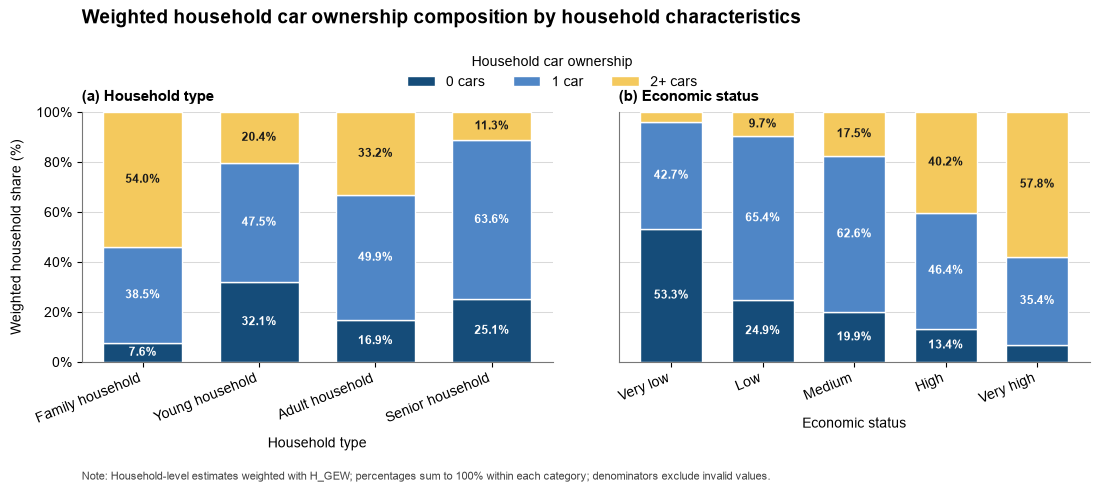

In [22]:
plot_dual_panel_car_ownership(
    left_share=hh_type_car_share_display,
    right_share=oek_car_share_display,
    output_path=OUTPUT_DIR / 'weighted_car_ownership_dual_panel.png',
    title='Weighted household car ownership composition by household characteristics',
    note='Note: Household-level estimates weighted with H_GEW; percentages sum to 100% within each category; denominators exclude invalid values.',
)


## 5. Spatial Context and Car Ownership

This EDA describes the weighted distribution of household car ownership across `RegioStaR7` spatial types. The analysis unit is the **household** and estimates are weighted with `H_GEW`.

The denominator is restricted to households with valid `RegioStaR7`, valid `car_count_group`, and valid positive numeric `H_GEW`. Percentages are conditional within each RegioStaR 7 row.

### Weighted row-share table

car_count_group,0 cars,1 car,2+ cars
RegioStaR7,,,
Urban region — metropolis,39.7%,47.5%,12.8%
Urban region — regiopolis / large city,27.4%,53.7%,18.9%
Urban region — medium-sized city / urban area,13.2%,52.8%,34.1%
Urban region — small-town / rural area,8.4%,50.2%,41.5%
Rural region — central city,20.6%,55.7%,23.7%
Rural region — medium-sized city / urban area,12.5%,53.3%,34.1%
Rural region — small-town / rural area,8.6%,50.6%,40.9%


### Publication-ready table: weighted row share with unweighted n

car_count_group,0 cars,1 car,2+ cars,Total unweighted N
RegioStaR7,,,,
Urban region — metropolis,"39.7% (n=10,501)","47.5% (n=19,239)","12.8% (n=7,716)",37456
Urban region — regiopolis / large city,"27.4% (n=8,351)","53.7% (n=23,376)","18.9% (n=13,328)",45055
Urban region — medium-sized city / urban area,"13.2% (n=4,948)","52.8% (n=30,832)","34.1% (n=30,630)",66410
Urban region — small-town / rural area,8.4% (n=478),"50.2% (n=4,755)","41.5% (n=6,477)",11710
Rural region — central city,"20.6% (n=1,726)","55.7% (n=7,036)","23.7% (n=5,102)",13864
Rural region — medium-sized city / urban area,"12.5% (n=1,661)","53.3% (n=11,549)","34.1% (n=12,281)",25491
Rural region — small-town / rural area,8.6% (n=812),"50.6% (n=7,197)","40.9% (n=10,044)",18053


**Total valid unweighted N:** 218,039 households.

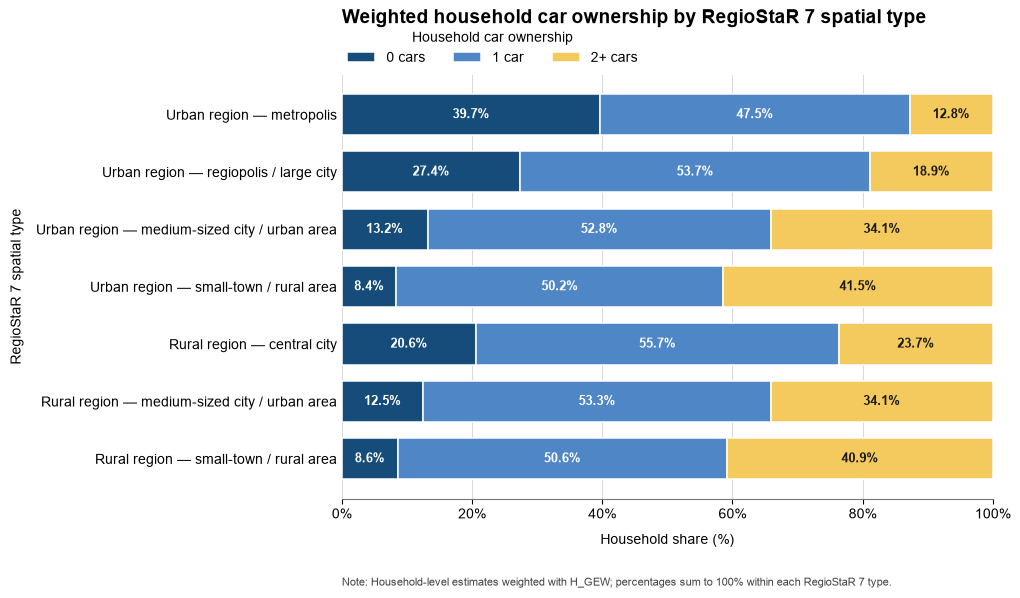

In [23]:
spatial_car_valid = make_valid_sample(
    hh,
    category_orders={'RegioStaR7': REGIOSTARR7_ORDER, 'car_count_group': CAR_COUNT_GROUP_ORDER},
)
spatial_car_share, spatial_car_n = weighted_row_share_crosstab(
    spatial_car_valid,
    index='RegioStaR7',
    columns='car_count_group',
    weight='H_GEW',
    index_order=REGIOSTARR7_ORDER,
    column_order=CAR_COUNT_GROUP_ORDER,
)
spatial_car_publication = make_publication_table(spatial_car_share, spatial_car_n)
spatial_car_publication_display = relabel_index(spatial_car_publication, {'RegioStaR7': REGIOSTARR7_LABELS})
spatial_car_share_display = relabel_index(spatial_car_share, {'RegioStaR7': REGIOSTARR7_LABELS})

spatial_car_publication_display.to_csv(OUTPUT_DIR / 'RQ1_05_regiostar7_by_car_count.csv')

display(Markdown('### Weighted row-share table'))
display(spatial_car_share_display.style.format('{:.1f}%'))
display(Markdown('### Publication-ready table: weighted row share with unweighted n'))
display(spatial_car_publication_display)
display(Markdown(f'**Total valid unweighted N:** {len(spatial_car_valid):,} households.'))

plot_100pct_stacked_bar(
    row_share=spatial_car_share_display,
    colors=CAR_COUNT_COLORS,
    title='Weighted household car ownership by RegioStaR 7 spatial type',
    xlabel='Household share (%)',
    ylabel='RegioStaR 7 spatial type',
    output_path=OUTPUT_DIR / 'RQ1_05_regiostar7_by_car_count_100pct.png',
    orientation='horizontal',
    figsize=(10.5, 6.625),
    note='Note: Household-level estimates weighted with H_GEW; percentages sum to 100% within each RegioStaR 7 type.',
)


## 6. Economic Status by Household Type and Car Ownership

This EDA checks whether the economic-status composition of households differs across car ownership levels within each household type. This is important because `oek_status`, `household_type`, and `car_count_group` may be associated, and this relationship informs variable selection for later MNL model specifications.

The analysis unit is the **household** and estimates are weighted with `H_GEW`. The denominator is restricted to households with valid `household_type`, valid `car_count_group`, valid `oek_status`, and valid positive numeric `H_GEW`. Weighted shares are conditional on each `household_type × car_count_group` group, so the economic-status distribution sums to 100% within each row.

### Weighted economic-status distribution

### Publication-ready table: weighted row share with unweighted n

Very low              Low  \
household_type   car_count_group                                     
Family household 0 cars             16.1% (n=217)    13.6% (n=224)   
                 1 car               4.3% (n=307)     8.3% (n=742)   
                 2+ cars             0.7% (n=100)     2.8% (n=442)   
Young household  0 cars           29.6% (n=1,624)    12.9% (n=876)   
                 1 car               9.0% (n=746)     9.1% (n=848)   
                 2+ cars              1.7% (n=91)     2.9% (n=187)   
Adult household  0 cars           25.7% (n=1,949)  12.0% (n=1,138)   
                 1 car             7.0% (n=1,858)  11.7% (n=3,773)   
                 2+ cars             1.4% (n=383)   3.5% (n=1,318)   
Senior household 0 cars           27.6% (n=2,305)  17.6% (n=1,668)   
                 1 car            10.5% (n=2,810)  21.3% (n=7,688)   
                 2+ cars             3.0% (n=250)     8.9% (n=909)   

                                            Medium              High  \
household_type   car_count_group                                       
Family household 0 cars              26.7% (n=483)     30.2% (n=676)   
                 1 car             29.3% (n=2,997)   39.1% (n=5,094)   
                 2+ cars           19.7% (n=3,204)   46.1% (n=8,320)   
Young household  0 cars            24.6% (n=1,698)   28.6% (n=2,148)   
                 1 car             38.1% (n=3,140)   35.1% (n=4,240)   
                 2+ cars             14.1% (n=912)   58.2% (n=4,050)   
Adult household  0 cars            26.5% (n=2,624)   29.5% (n=3,455)   
                 1 car            32.5% (n=12,185)  38.2% (n=17,347)   
                 2+ cars           16.0% (n=6,695)  52.5% (n=23,995)   
Senior household 0 cars            38.6% (n=3,669)   15.1% (n=1,649)   
                 1 car            43.8% (n=17,286)  21.2% (n=10,134)   
                 2+ cars           31.1% (n=4,242)   44.1% (n=6,091)   

                                         Very high  Total unweighted N  
household_type   car_count_group                                        
Family household 0 cars              13.5% (n=356)                1956  
                 1 car             18.9% (n=3,066)               12206  
                 2+ cars           30.6% (n=6,705)               18771  
Young household  0 cars               4.2% (n=509)                6855  
                 1 car              8.7% (n=1,619)               10593  
                 2+ cars           23.1% (n=2,043)                7283  
Adult household  0 cars             6.3% (n=1,068)               10234  
                 1 car             10.6% (n=6,246)               41409  
                 2+ cars          26.6% (n=13,597)               45988  
Senior household 0 cars               1.1% (n=141)                9432  
                 1 car              3.2% (n=1,856)               39774  
                 2+ cars           12.9% (n=2,042)               13534

**Total valid unweighted N:** 218,035 households.

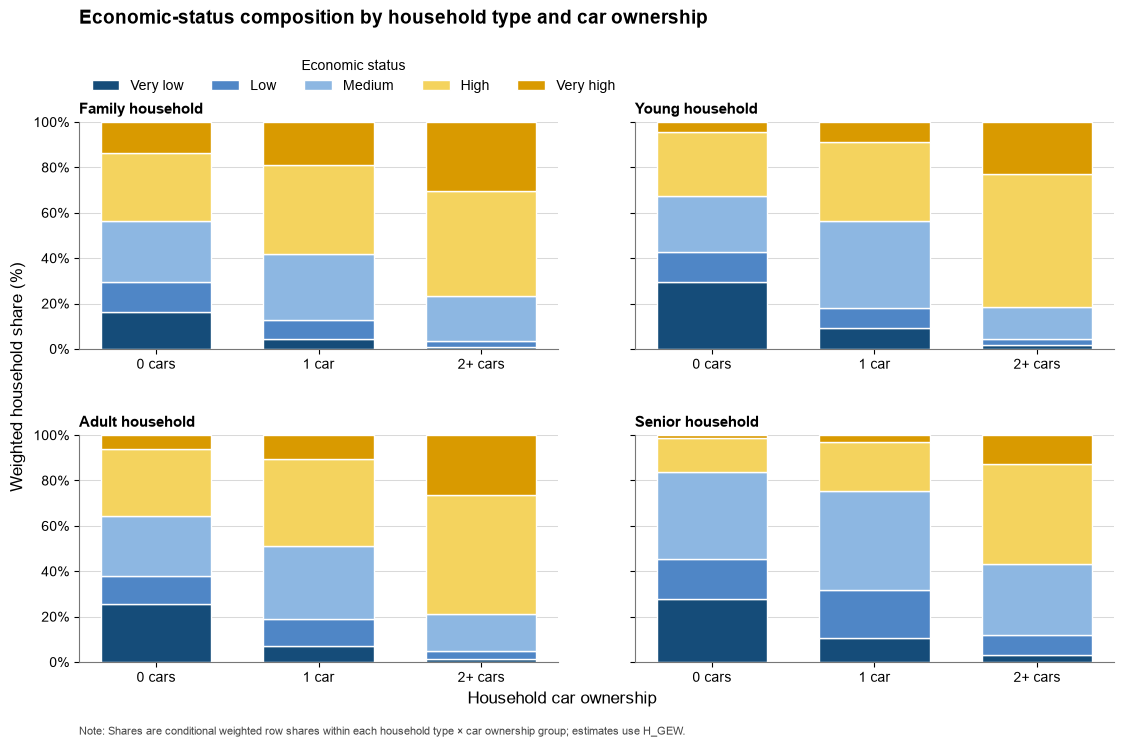

In [24]:
oek_valid = make_valid_sample(
    hh,
    category_orders={
        'household_type': HOUSEHOLD_TYPE4_ORDER,
        'car_count_group': CAR_COUNT_GROUP_ORDER,
        'oek_status': OEK_STATUS_ORDER,
    },
)
oek_share, oek_n = weighted_row_share_crosstab(
    oek_valid,
    index=['household_type', 'car_count_group'],
    columns='oek_status',
    weight='H_GEW',
    index_order=[HOUSEHOLD_TYPE4_ORDER, CAR_COUNT_GROUP_ORDER],
    column_order=OEK_STATUS_ORDER,
)

oek_publication = make_publication_table(oek_share, oek_n)
oek_publication_display = relabel_index(oek_publication, {'household_type': HOUSEHOLD_TYPE_LABELS})
oek_publication_display = relabel_columns(oek_publication_display, OEK_STATUS_LABELS)
oek_share_display = relabel_index(oek_share, {'household_type': HOUSEHOLD_TYPE_LABELS})
oek_share_display = relabel_columns(oek_share_display, OEK_STATUS_LABELS)

oek_publication_display.to_csv(OUTPUT_DIR / 'RQ1_06_oek_status_by_household_type_car_count.csv')

display(Markdown('### Weighted economic-status distribution'))
display(oek_share_display.style.format('{:.1f}%'))
display(Markdown('### Publication-ready table: weighted row share with unweighted n'))
display(oek_publication_display)
display(Markdown(f'**Total valid unweighted N:** {len(oek_valid):,} households.'))

oek_plot_share = oek_share.copy()
oek_plot_share.columns = [OEK_STATUS_LABELS[col] for col in oek_plot_share.columns]
plot_faceted_100pct_stacked(
    row_share=oek_plot_share,
    facet_order=HOUSEHOLD_TYPE4_ORDER,
    x_order=CAR_COUNT_GROUP_ORDER,
    segment_order=[OEK_STATUS_LABELS[x] for x in OEK_STATUS_ORDER],
    facet_labels=HOUSEHOLD_TYPE_LABELS,
    colors=OEK_STATUS_COLORS,
    title='Economic-status composition by household type and car ownership',
    output_path=OUTPUT_DIR / 'RQ1_06_oek_status_by_household_type_car_count_100pct.png',
    note='Note: Shares are conditional weighted row shares within each household type × car ownership group; estimates use H_GEW.',
)


In [25]:
high_status_share = oek_share[[4, 5]].sum(axis=1).unstack('car_count_group').reindex(index=HOUSEHOLD_TYPE4_ORDER, columns=CAR_COUNT_GROUP_ORDER)
gradient_2plus_vs_0car = (high_status_share['2+ cars'] - high_status_share['0 cars']).sort_values(ascending=False)
strongest_type = gradient_2plus_vs_0car.index[0]
weakest_type = gradient_2plus_vs_0car.index[-1]

gradient_lines = []
for hh_type in HOUSEHOLD_TYPE4_ORDER:
    gradient_lines.append(
        f"- **{HOUSEHOLD_TYPE_LABELS[hh_type]}:** high/very-high economic-status share is "
        f"{high_status_share.loc[hh_type, '0 cars']:.1f}% for 0-car households, "
        f"{high_status_share.loc[hh_type, '1 car']:.1f}% for 1-car households, and "
        f"{high_status_share.loc[hh_type, '2+ cars']:.1f}% for 2+ car households."
    )

display(Markdown(
    '### Brief interpretation\n\n'
    'Across household types, the table and figure describe whether households with more cars also have a higher weighted share of high or very-high economic status.\n\n'
    + '\n'.join(gradient_lines)
    + '\n\n'
    f'The 2+ car versus 0-car high-status gradient appears strongest for **{HOUSEHOLD_TYPE_LABELS[strongest_type]}** '
    f'({gradient_2plus_vs_0car.loc[strongest_type]:.1f} percentage points) and weakest for **{HOUSEHOLD_TYPE_LABELS[weakest_type]}** '
    f'({gradient_2plus_vs_0car.loc[weakest_type]:.1f} percentage points). '
    'This is a descriptive association, not causal evidence. For later MNL specifications, the pattern supports treating `oek_status` as a socioeconomic control while recognizing that it may overlap empirically with both `household_type` and `car_count_group`.'
))


### Brief interpretation

Across household types, the table and figure describe whether households with more cars also have a higher weighted share of high or very-high economic status.

- **Family household:** high/very-high economic-status share is 43.7% for 0-car households, 58.1% for 1-car households, and 76.7% for 2+ car households.
- **Young household:** high/very-high economic-status share is 32.8% for 0-car households, 43.8% for 1-car households, and 81.3% for 2+ car households.
- **Adult household:** high/very-high economic-status share is 35.8% for 0-car households, 48.8% for 1-car households, and 79.1% for 2+ car households.
- **Senior household:** high/very-high economic-status share is 16.2% for 0-car households, 24.5% for 1-car households, and 56.9% for 2+ car households.

The 2+ car versus 0-car high-status gradient appears strongest for **Young household** (48.5 percentage points) and weakest for **Family household** (33.0 percentage points). This is a descriptive association, not causal evidence. For later MNL specifications, the pattern supports treating `oek_status` as a socioeconomic control while recognizing that it may overlap empirically with both `household_type` and `car_count_group`.